<a href="https://colab.research.google.com/github/Bhavyashree1507/IPL-Cricket-Statistics-Dashboard/blob/main/Copy_of_IPL_Cricket_statistics__dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("IPL Dashboard Project Started!")

IPL Dashboard Project Started!


In [ ]:
import requests
import zipfile
import io

url = "https://cricsheet.org/downloads/ipl_json.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("ipl_data")

print("IPL data downloaded successfully!")

IPL data downloaded successfully!


In [ ]:
import os

files = os.listdir("ipl_data")

print("Number of files:", len(files))
print("First 10 files:")
print(files[:10])

Number of files: 1244
First 10 files:
['1304053.json', '733989.json', '1254091.json', '1254060.json', '336038.json', '501236.json', '1254062.json', '1216534.json', '1304050.json', '392207.json']


In [ ]:
import json
import glob
import pandas as pd

rows = []

for file in glob.glob("ipl_data/*.json"):
    with open(file, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]

    # Use only IPL matches
    if info.get("event", {}).get("name") != "Indian Premier League":
        continue

    season = info.get("season")
    teams = info.get("teams", [])

    # Match result
    winner = info.get("outcome", {}).get("winner")

    rows.append({
        "match_id": file.split("/")[-1].replace(".json", ""),
        "season": season,
        "team1": teams[0] if len(teams) > 0 else None,
        "team2": teams[1] if len(teams) > 1 else None,
        "winner": winner
    })

matches = pd.DataFrame(rows)

print("IPL matches:", len(matches))
print(matches.head())

IPL matches: 1243
  match_id   season                  team1                 team2  \
0  1304053     2022    Chennai Super Kings  Lucknow Super Giants   
1   733989     2014       Rajasthan Royals   Sunrisers Hyderabad   
2  1254091     2021    Sunrisers Hyderabad   Chennai Super Kings   
3  1254060     2021  Kolkata Knight Riders   Sunrisers Hyderabad   
4   336038  2007/08       Delhi Daredevils      Rajasthan Royals   

                  winner  
0   Lucknow Super Giants  
1    Sunrisers Hyderabad  
2    Chennai Super Kings  
3  Kolkata Knight Riders  
4       Rajasthan Royals  


In [ ]:
import json
import glob
from collections import defaultdict

player_runs = defaultdict(int)
player_wickets = defaultdict(int)
match_runs = defaultdict(int)

for file in glob.glob("ipl_data/*.json"):
    with open(file, "r", encoding="utf-8") as f:
        match = json.load(f)

    info = match["info"]

    if info.get("event", {}).get("name") != "Indian Premier League":
        continue

    match_id = file.split("/")[-1].replace(".json", "")

    for innings in match.get("innings", []):
        for over in innings.get("overs", []):
            for delivery in over.get("deliveries", []):

                batter = delivery["batter"]
                bowler = delivery["bowler"]
                runs = delivery["runs"]

                # Batter runs
                player_runs[batter] += runs["batter"]

                # Total match runs
                match_runs[match_id] += runs["total"]

                # Wickets
                for wicket in delivery.get("wickets", []):
                    kind = wicket["kind"]

                    # Exclude run out, retired hurt, obstructing the field
                    if kind not in [
                        "run out",
                        "retired hurt",
                        "retired out",
                        "obstructing the field"
                    ]:
                        player_wickets[bowler] += 1

print("Player runs calculated:", len(player_runs))
print("Player wickets calculated:", len(player_wickets))
print("Match totals calculated:", len(match_runs))

Player runs calculated: 738
Player wickets calculated: 491
Match totals calculated: 1243


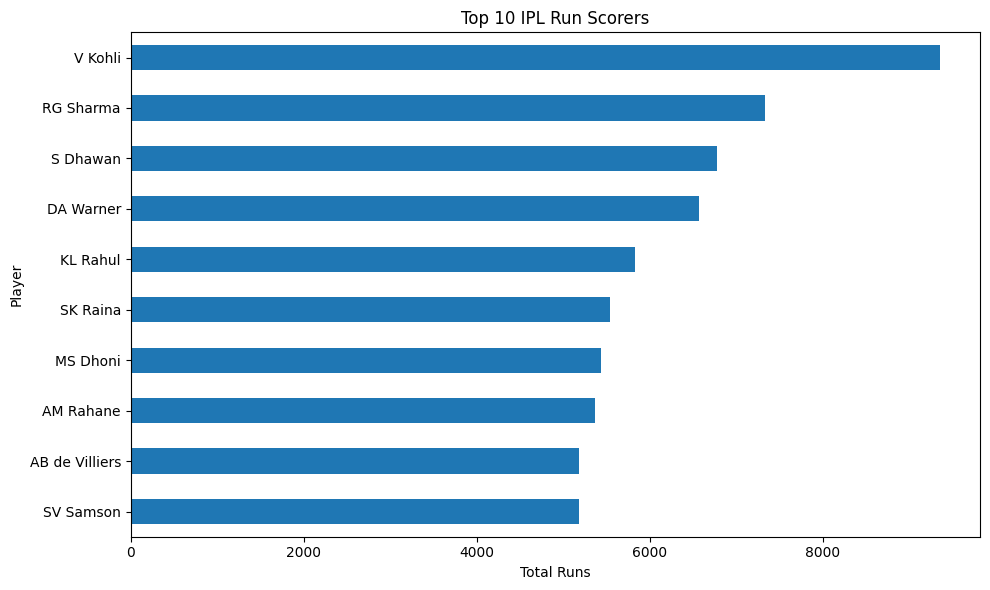

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

top_run_scorers = (
    pd.Series(player_runs)
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_run_scorers.plot(kind="barh")

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Player")
plt.tight_layout()

plt.savefig("top_10_run_scorers.png", dpi=300)
plt.show()

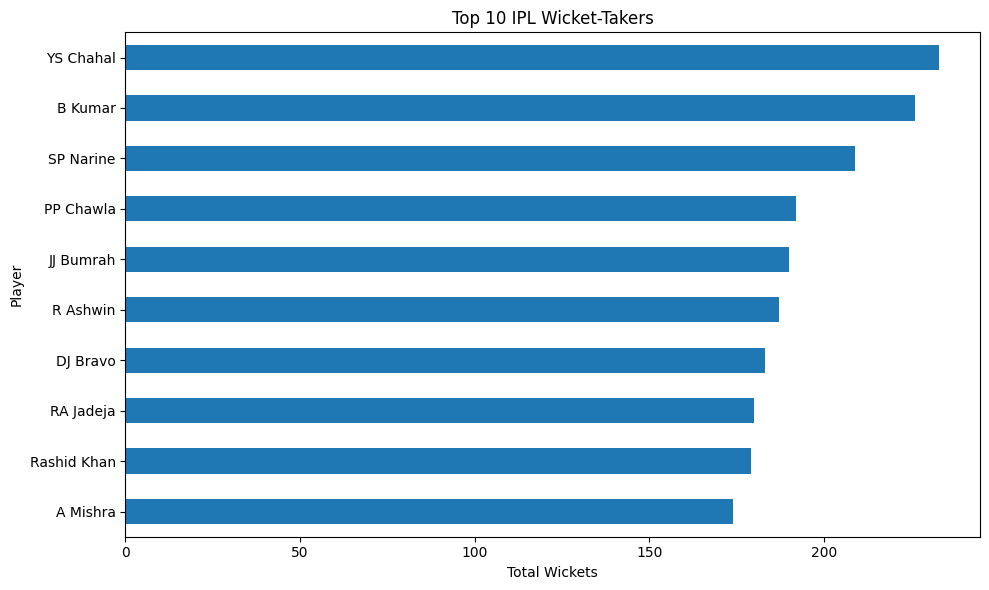

In [ ]:
top_wicket_takers = (
    pd.Series(player_wickets)
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_wicket_takers.plot(kind="barh")

plt.title("Top 10 IPL Wicket-Takers")
plt.xlabel("Total Wickets")
plt.ylabel("Player")
plt.tight_layout()

plt.savefig("top_10_wicket_takers.png", dpi=300)
plt.show()

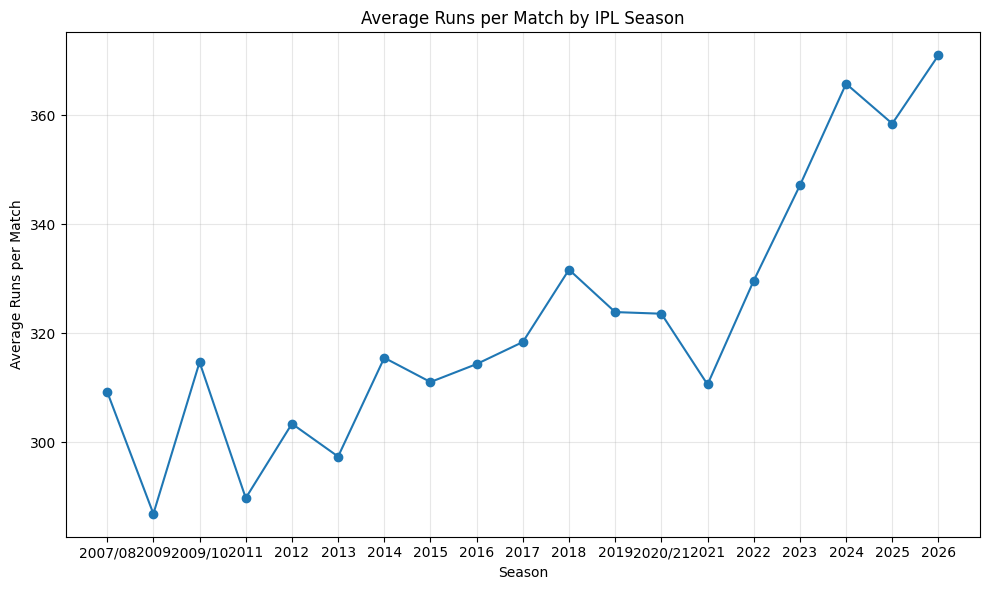

In [ ]:
# Add total runs to each match
matches["total_runs"] = matches["match_id"].map(match_runs)

# Calculate average runs per match for each season
runs_per_season = (
    matches.groupby("season")["total_runs"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    runs_per_season["season"],
    runs_per_season["total_runs"],
    marker="o"
)

plt.title("Average Runs per Match by IPL Season")
plt.xlabel("Season")
plt.ylabel("Average Runs per Match")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("runs_per_match.png", dpi=300)
plt.show()

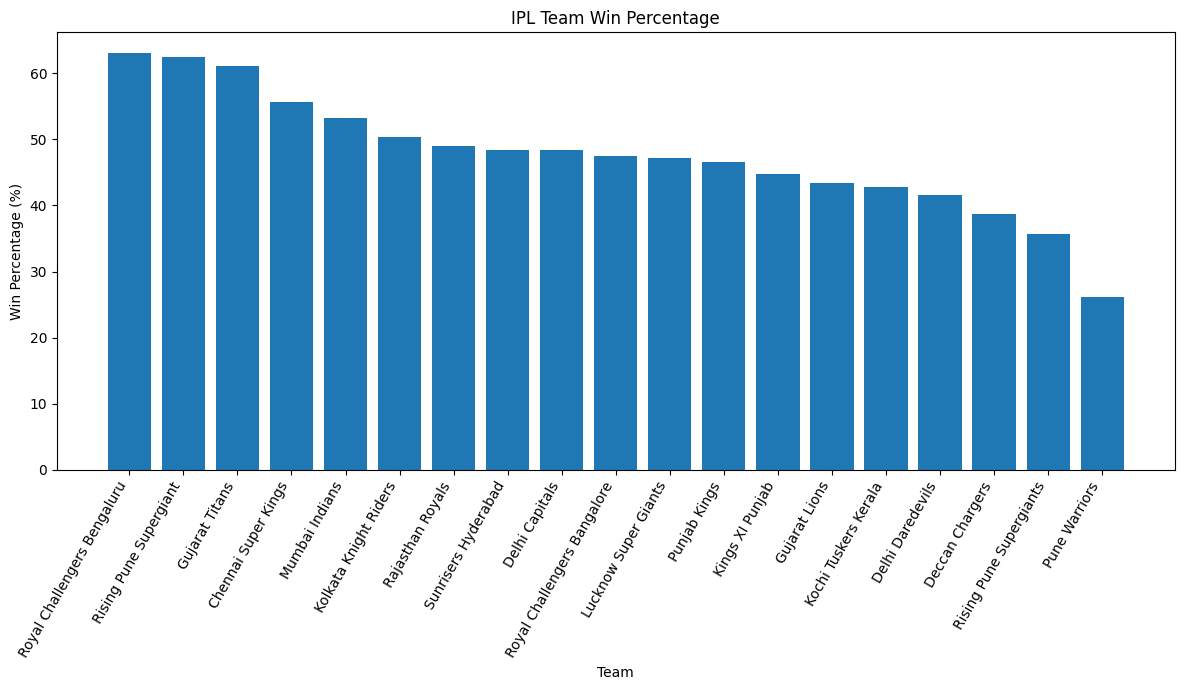

In [ ]:
# Count matches played by each team

team_matches = {}

for _, row in matches.iterrows():
    for team in [row["team1"], row["team2"]]:
        if team:
            team_matches[team] = team_matches.get(team, 0) + 1

# Count wins by each team
team_wins = matches["winner"].value_counts().to_dict()

# Calculate win percentage
team_win_data = []

for team, played in team_matches.items():
    wins = team_wins.get(team, 0)
    win_percentage = (wins / played) * 100

    team_win_data.append({
        "team": team,
        "matches": played,
        "wins": wins,
        "win_percentage": win_percentage
    })

team_win_df = pd.DataFrame(team_win_data)

# Sort by win percentage
team_win_df = team_win_df.sort_values(
    "win_percentage",
    ascending=False
)

# Create chart
plt.figure(figsize=(12, 7))

plt.bar(
    team_win_df["team"],
    team_win_df["win_percentage"]
)

plt.title("IPL Team Win Percentage")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.savefig("team_win_percentage.png", dpi=300)
plt.show()

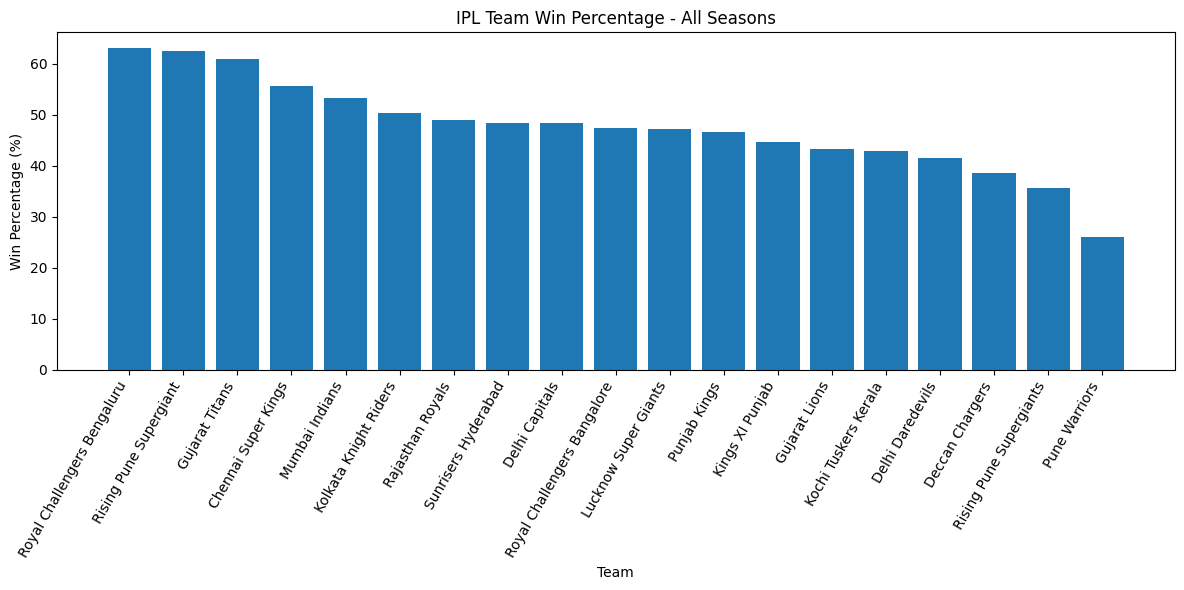

Selected Season: All Seasons
Matches: 1243


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create season list
season_list = sorted(
    matches["season"].dropna().astype(str).unique()
)

season_dropdown = widgets.Dropdown(
    options=["All Seasons"] + season_list,
    value="All Seasons",
    description="Season:"
)

output = widgets.Output()

def show_dashboard(change=None):

    with output:
        clear_output(wait=True)

        selected = season_dropdown.value

        if selected == "All Seasons":
            data = matches.copy()
        else:
            data = matches[
                matches["season"].astype(str) == selected
            ]

        # Team win percentage
        played = {}

        for _, row in data.iterrows():
            for team in [row["team1"], row["team2"]]:
                if pd.notna(team):
                    played[team] = played.get(team, 0) + 1

        wins = data["winner"].value_counts().to_dict()

        win_data = []

        for team in played:
            total = played[team]
            win = wins.get(team, 0)

            win_data.append({
                "team": team,
                "win_percentage": (win / total) * 100
            })

        win_df = pd.DataFrame(win_data)
        win_df = win_df.sort_values(
            "win_percentage",
            ascending=False
        )

        # Display chart
        plt.figure(figsize=(12, 6))

        plt.bar(
            win_df["team"],
            win_df["win_percentage"]
        )

        plt.title(
            "IPL Team Win Percentage - " + selected
        )
        plt.xlabel("Team")
        plt.ylabel("Win Percentage (%)")
        plt.xticks(rotation=60, ha="right")

        plt.tight_layout()
        plt.show()

        print("Selected Season:", selected)
        print("Matches:", len(data))


season_dropdown.observe(
    show_dashboard,
    names="value"
)

display(season_dropdown)
display(output)

show_dashboard()

In [ ]:
import json
import glob
import pandas as pd
from collections import defaultdict

rows = []
match_runs = defaultdict(int)

for file in glob.glob("ipl_data/*.json"):

    try:
        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        info = match["info"]

        # IPL match must have season and teams
        season = info.get("season")
        teams = info.get("teams", [])

        if season is None or len(teams) < 2:
            continue

        match_id = file.split("/")[-1].replace(".json", "")

        rows.append({
            "match_id": str(match_id),
            "season": str(season),
            "team1": teams[0],
            "team2": teams[1],
            "winner": info.get("outcome", {}).get("winner")
        })

        for innings in match.get("innings", []):
            for over in innings.get("overs", []):
                for delivery in over.get("deliveries", []):
                    match_runs[str(match_id)] += delivery["runs"]["total"]

    except Exception:
        pass

# Create fresh dataframe
matches = pd.DataFrame(
    rows,
    columns=["match_id", "season", "team1", "team2", "winner"]
)

matches["total_runs"] = matches["match_id"].map(match_runs)

print("Matches:", len(matches))
print("Columns:", matches.columns.tolist())
print()
print("Seasons:")
print(matches["season"].unique())

Matches: 1243
Columns: ['match_id', 'season', 'team1', 'team2', 'winner', 'total_runs']

Seasons:
['2022' '2014' '2021' '2007/08' '2011' '2020/21' '2009' '2013' '2023'
 '2025' '2018' '2017' '2015' '2012' '2016' '2019' '2009/10' '2026' '2024']


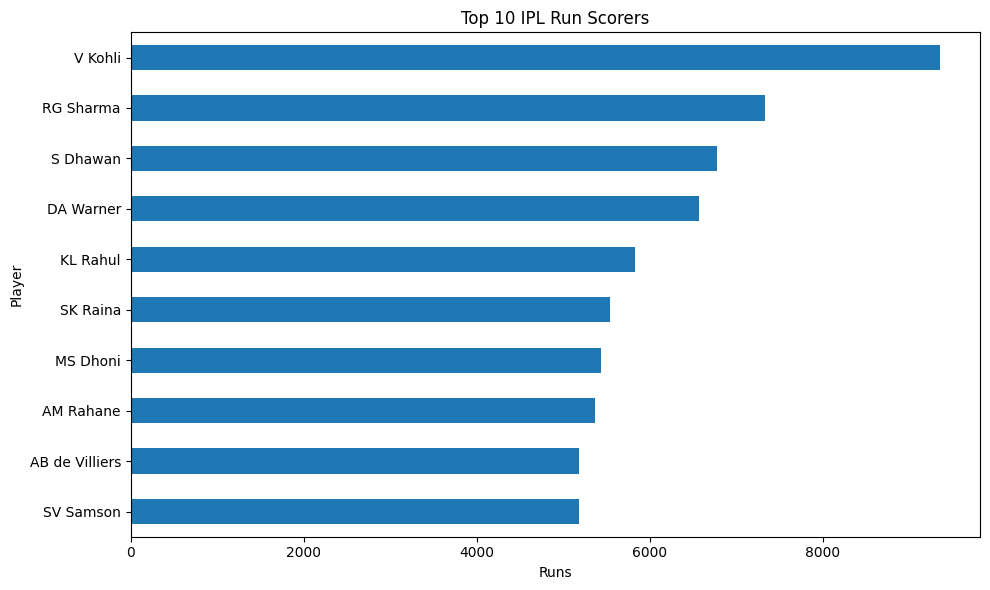

In [ ]:
def get_run_scorers(data):
    selected_ids = set(data["match_id"].astype(str))

    runs = {}

    for file in glob.glob("ipl_data/*.json"):
        match_id = file.split("/")[-1].replace(".json", "")

        if match_id not in selected_ids:
            continue

        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        for innings in match.get("innings", []):
            for over in innings.get("overs", []):
                for delivery in over.get("deliveries", []):
                    player = delivery["batter"]
                    runs[player] = runs.get(player, 0) + delivery["runs"]["batter"]

    return pd.Series(runs).sort_values(ascending=False).head(10)


top_runs = get_run_scorers(matches)

plt.figure(figsize=(10, 6))
top_runs.sort_values().plot(kind="barh")

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

seasons = sorted(matches["season"].astype(str).unique())

season_filter = widgets.Dropdown(
    options=["All Seasons"] + seasons,
    value="All Seasons",
    description="Season:"
)

display(season_filter)

Dropdown(description='Season:', options=('All Seasons', '2007/08', '2009', '2009/10', '2011', '2012', '2013', …

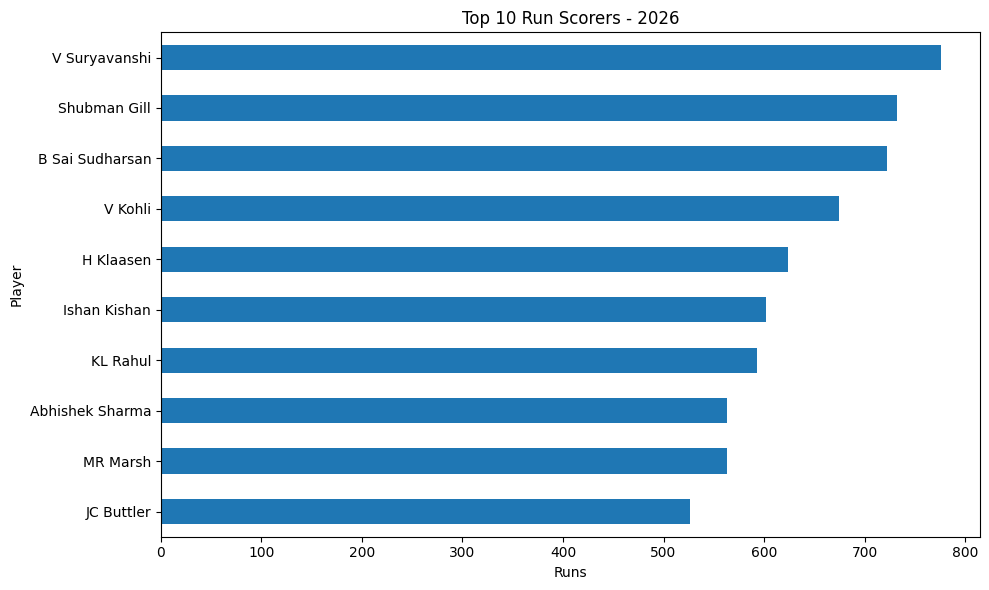

In [ ]:
def get_run_scorers(data):

    selected_ids = set(data["match_id"].astype(str))
    runs = {}

    for file in glob.glob("ipl_data/*.json"):

        match_id = file.split("/")[-1].replace(".json", "")

        if match_id not in selected_ids:
            continue

        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        for innings in match.get("innings", []):
            for over in innings.get("overs", []):
                for delivery in over.get("deliveries", []):

                    player = delivery["batter"]
                    runs[player] = runs.get(player, 0) + delivery["runs"]["batter"]

    return pd.Series(runs).sort_values(ascending=False).head(10)


selected = season_filter.value

if selected == "All Seasons":
    data = matches.copy()
else:
    data = matches[matches["season"].astype(str) == selected]

top_runs = get_run_scorers(data)

plt.figure(figsize=(10, 6))
top_runs.sort_values().plot(kind="barh")

plt.title("Top 10 Run Scorers - " + selected)
plt.xlabel("Runs")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

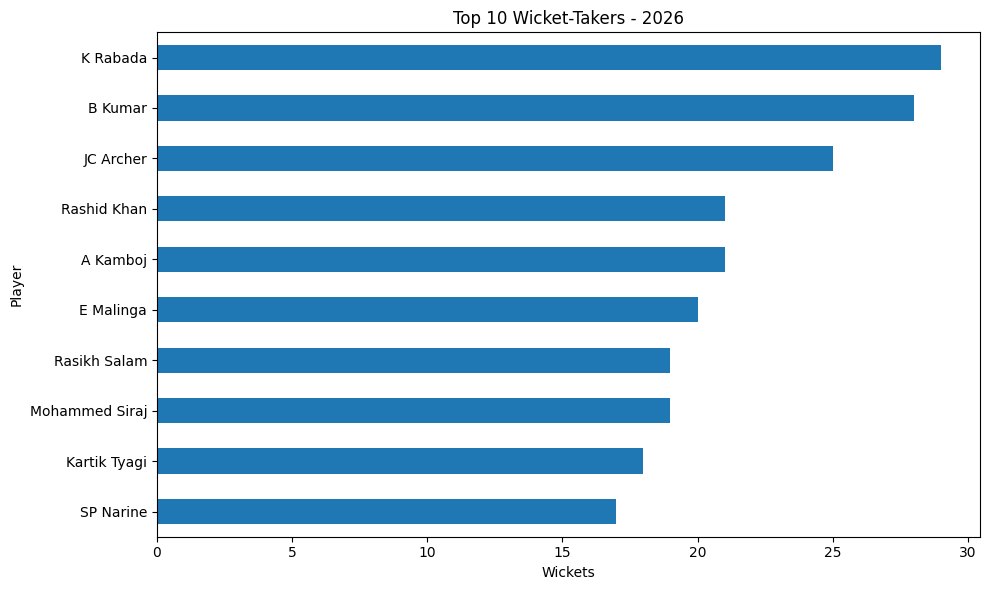

In [ ]:
def get_wicket_takers(data):

    selected_ids = set(data["match_id"].astype(str))
    wickets = {}

    for file in glob.glob("ipl_data/*.json"):

        match_id = file.split("/")[-1].replace(".json", "")

        if match_id not in selected_ids:
            continue

        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        for innings in match.get("innings", []):
            for over in innings.get("overs", []):
                for delivery in over.get("deliveries", []):

                    bowler = delivery["bowler"]

                    for wicket in delivery.get("wickets", []):
                        kind = wicket["kind"]

                        if kind not in [
                            "run out",
                            "retired hurt",
                            "retired out",
                            "obstructing the field"
                        ]:
                            wickets[bowler] = wickets.get(bowler, 0) + 1

    return pd.Series(wickets).sort_values(ascending=False).head(10)


selected = season_filter.value

if selected == "All Seasons":
    data = matches.copy()
else:
    data = matches[matches["season"].astype(str) == selected]

top_wickets = get_wicket_takers(data)

plt.figure(figsize=(10, 6))
top_wickets.sort_values().plot(kind="barh")

plt.title("Top 10 Wicket-Takers - " + selected)
plt.xlabel("Wickets")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

dashboard_output = widgets.Output()

def update_dashboard(change=None):

    with dashboard_output:
        clear_output(wait=True)

        selected = season_filter.value

        if selected == "All Seasons":
            data = matches.copy()
        else:
            data = matches[
                matches["season"].astype(str) == selected
            ]

        # Count matches played by each team
        played = {}

        for _, row in data.iterrows():
            for team in [row["team1"], row["team2"]]:
                if pd.notna(team):
                    played[team] = played.get(team, 0) + 1

        # Count wins
        wins = data["winner"].value_counts().to_dict()

        # Calculate win percentage
        win_data = []

        for team, total in played.items():
            win_count = wins.get(team, 0)

            win_data.append({
                "team": team,
                "win_percentage": (win_count / total) * 100
            })

        win_df = pd.DataFrame(win_data)

        win_df = win_df.sort_values(
            "win_percentage",
            ascending=False
        )

        # Plot
        plt.figure(figsize=(12, 6))

        plt.bar(
            win_df["team"],
            win_df["win_percentage"]
        )

        plt.title(
            "Team Win Percentage - " + selected
        )

        plt.xlabel("Team")
        plt.ylabel("Win Percentage (%)")

        plt.xticks(
            rotation=60,
            ha="right"
        )

        plt.tight_layout()
        plt.show()

        print("Selected Season:", selected)
        print("Matches:", len(data))


season_filter.observe(
    update_dashboard,
    names="value"
)

display(dashboard_output)

update_dashboard()

Output()

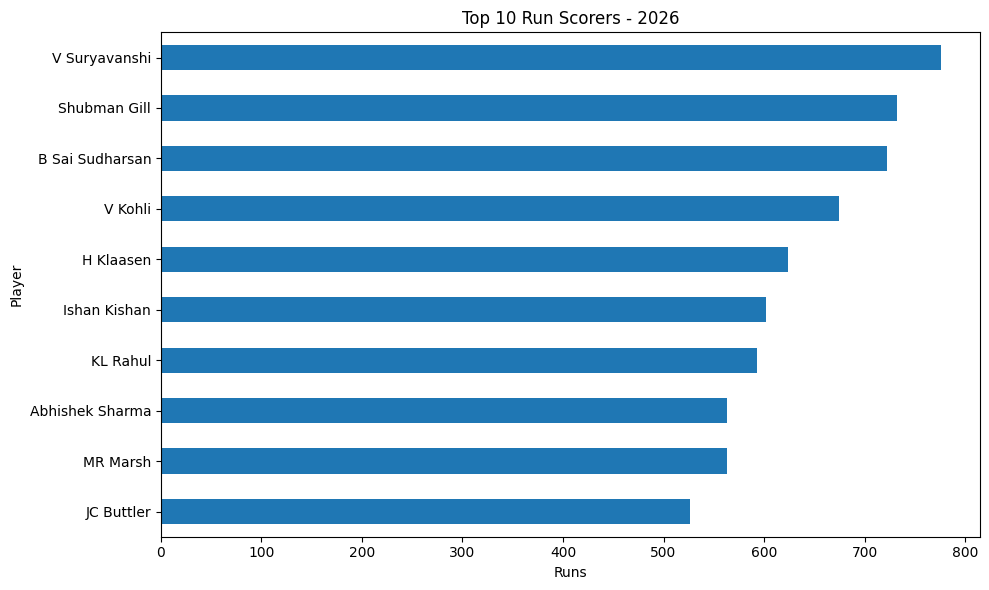

In [ ]:
def get_run_scorers(data):

    selected_ids = set(data["match_id"].astype(str))
    runs = {}

    for file in glob.glob("ipl_data/*.json"):

        match_id = file.split("/")[-1].replace(".json", "")

        if match_id not in selected_ids:
            continue

        with open(file, "r", encoding="utf-8") as f:
            match = json.load(f)

        for innings in match.get("innings", []):
            for over in innings.get("overs", []):
                for delivery in over.get("deliveries", []):

                    player = delivery["batter"]

                    runs[player] = (
                        runs.get(player, 0)
                        + delivery["runs"]["batter"]
                    )

    return pd.Series(runs).sort_values(
        ascending=False
    ).head(10)


selected = season_filter.value

if selected == "All Seasons":
    data = matches.copy()
else:
    data = matches[
        matches["season"].astype(str) == selected
    ]

top_runs = get_run_scorers(data)

plt.figure(figsize=(10, 6))

top_runs.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Run Scorers - " + selected
)

plt.xlabel("Runs")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

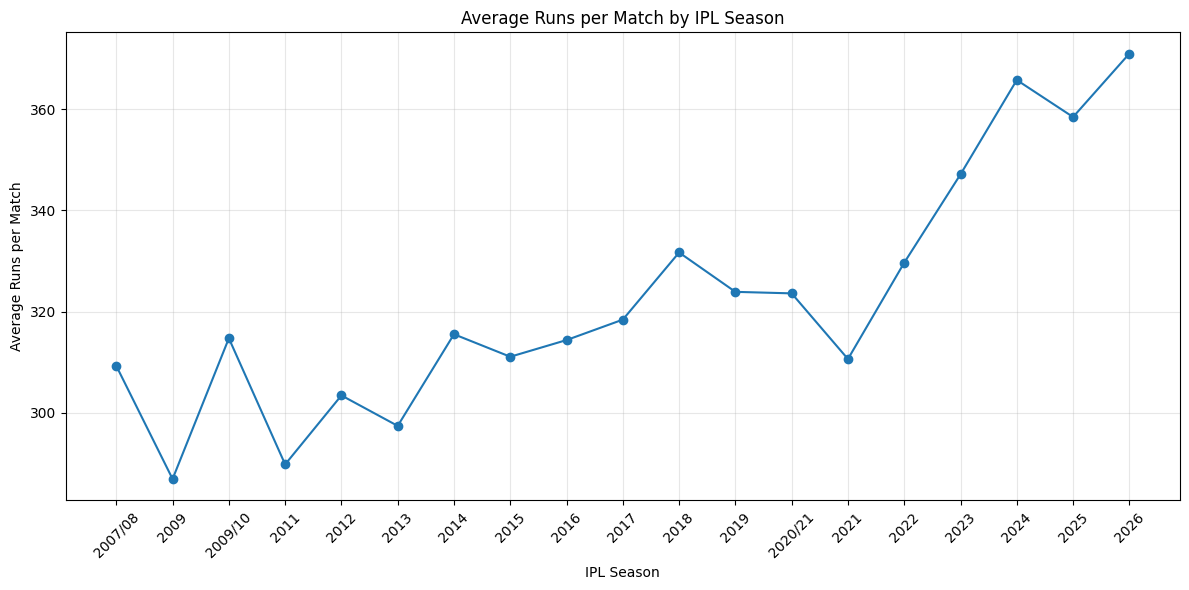

In [ ]:
runs_per_season = (
    matches.groupby("season")["total_runs"]
    .mean()
    .reset_index()
)

runs_per_season["season"] = runs_per_season["season"].astype(str)

x = range(len(runs_per_season))

plt.figure(figsize=(12, 6))

plt.plot(
    x,
    runs_per_season["total_runs"],
    marker="o"
)

plt.xticks(
    x,
    runs_per_season["season"],
    rotation=45
)

plt.title("Average Runs per Match by IPL Season")
plt.xlabel("IPL Season")
plt.ylabel("Average Runs per Match")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

dashboard = widgets.Output()

def create_dashboard(change=None):

    with dashboard:
        clear_output(wait=True)

        selected = season_filter.value

        # Select season
        if selected == "All Seasons":
            data = matches.copy()
        else:
            data = matches[
                matches["season"].astype(str) == selected
            ]

        # -------------------------
        # 1. Team Win Percentage
        # -------------------------
        played = {}

        for _, row in data.iterrows():
            for team in [row["team1"], row["team2"]]:
                if pd.notna(team):
                    played[team] = played.get(team, 0) + 1

        wins = data["winner"].value_counts().to_dict()

        win_data = []

        for team, total in played.items():
            win_data.append({
                "team": team,
                "win_percentage":
                    (wins.get(team, 0) / total) * 100
            })

        win_df = pd.DataFrame(win_data)
        win_df = win_df.sort_values(
            "win_percentage",
            ascending=False
        )

        # -------------------------
        # 2. Runs per Season
        # -------------------------
        runs_per_season = (
            data.groupby("season")["total_runs"]
            .mean()
            .reset_index()
        )

        # -------------------------
        # Display charts
        # -------------------------

        print("IPL CRICKET STATISTICS DASHBOARD")
        print("Selected Season:", selected)
        print("Matches:", len(data))

        # Chart 1
        plt.figure(figsize=(10, 5))
        plt.bar(
            win_df["team"],
            win_df["win_percentage"]
        )
        plt.title("Team Win Percentage")
        plt.ylabel("Win Percentage (%)")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()

        # Chart 2
        top_runs = get_run_scorers(data)

        plt.figure(figsize=(10, 5))
        top_runs.sort_values().plot(kind="barh")
        plt.title("Top 10 Run Scorers")
        plt.xlabel("Runs")
        plt.tight_layout()
        plt.show()

        # Chart 3
        top_wickets = get_wicket_takers(data)

        plt.figure(figsize=(10, 5))
        top_wickets.sort_values().plot(kind="barh")
        plt.title("Top 10 Wicket-Takers")
        plt.xlabel("Wickets")
        plt.tight_layout()
        plt.show()

        # Chart 4
        plt.figure(figsize=(10, 5))
        plt.plot(
            runs_per_season["season"].astype(str),
            runs_per_season["total_runs"],
            marker="o"
        )
        plt.title("Average Runs per Match")
        plt.xlabel("Season")
        plt.ylabel("Average Runs")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


season_filter.observe(
    create_dashboard,
    names="value"
)

display(season_filter)
display(dashboard)

create_dashboard()

Dropdown(description='Season:', index=2, options=('All Seasons', '2007/08', '2009', '2009/10', '2011', '2012',…

Output()

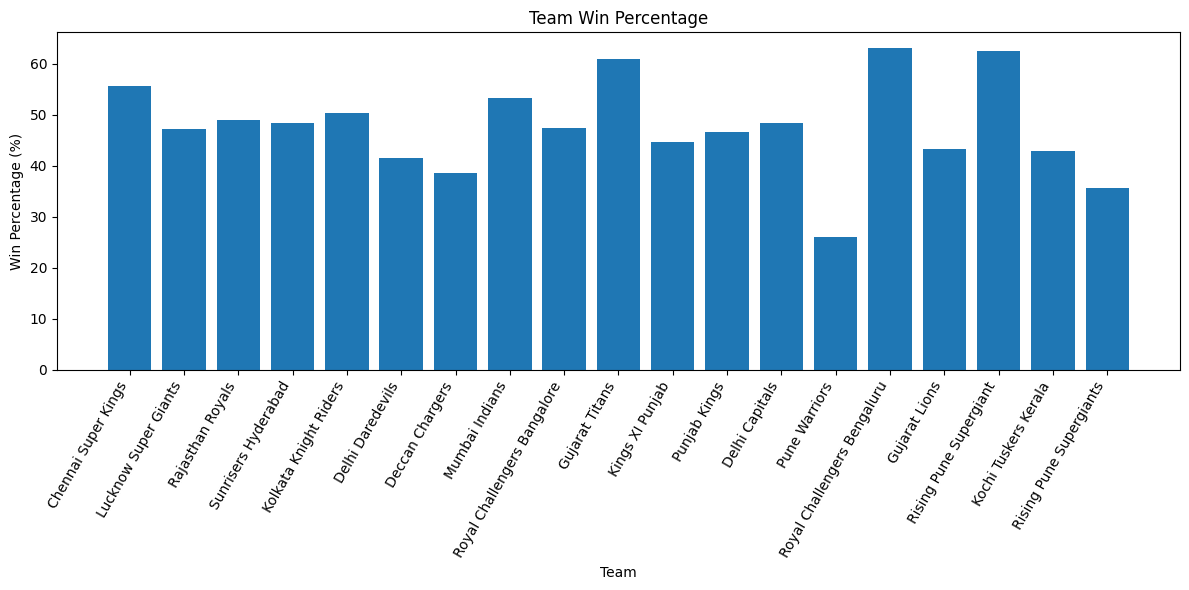

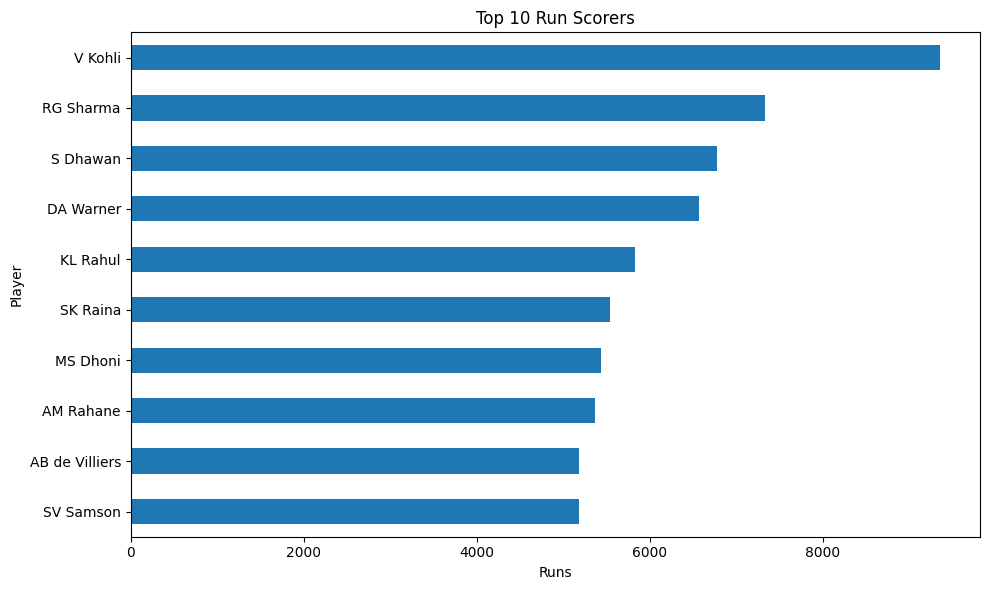

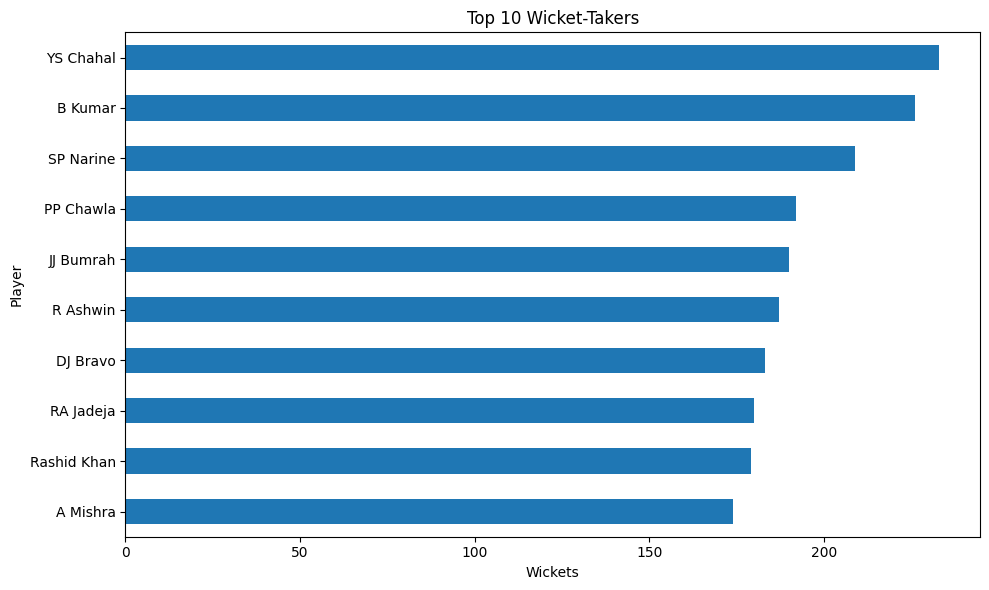

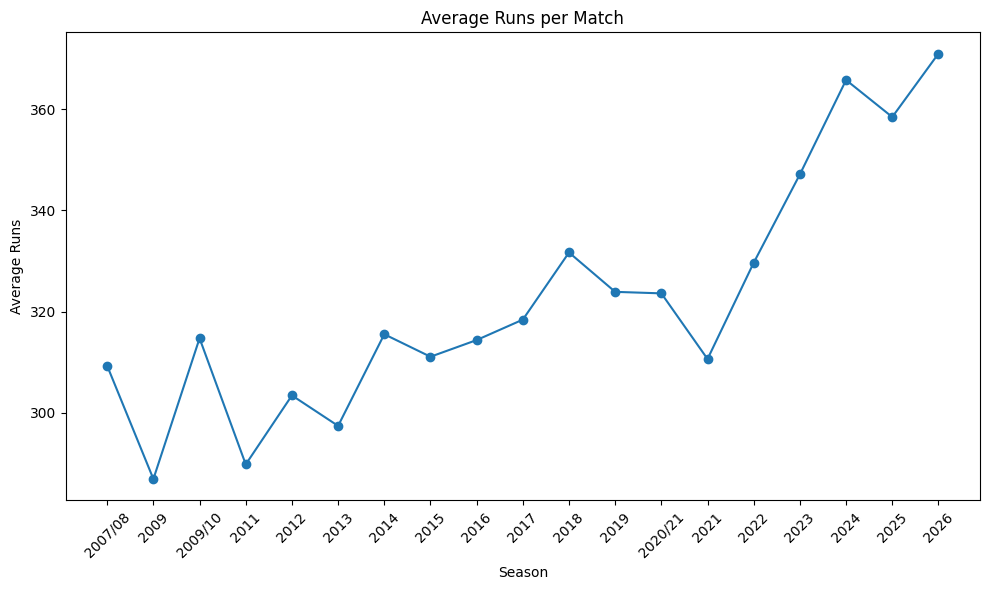

✅ All 4 PNG files saved successfully!


In [ ]:
import os

os.makedirs("outputs", exist_ok=True)

# Get currently selected season
selected = season_filter.value

if selected == "All Seasons":
    data = matches.copy()
else:
    data = matches[
        matches["season"].astype(str) == selected
    ]

# -------------------------
# TEAM WIN PERCENTAGE
# -------------------------
played = {}

for _, row in data.iterrows():
    for team in [row["team1"], row["team2"]]:
        if pd.notna(team):
            played[team] = played.get(team, 0) + 1

wins = data["winner"].value_counts().to_dict()

win_data = []

for team, total in played.items():
    win_data.append({
        "team": team,
        "win_percentage": (wins.get(team, 0) / total) * 100
    })

win_df = pd.DataFrame(win_data)

# -------------------------
# TOP RUNS
# -------------------------
top_runs = get_run_scorers(data)

# -------------------------
# TOP WICKETS
# -------------------------
top_wickets = get_wicket_takers(data)

# -------------------------
# 1. TEAM WIN %
# -------------------------
plt.figure(figsize=(12, 6))
plt.bar(win_df["team"], win_df["win_percentage"])
plt.title("Team Win Percentage")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("outputs/team_win_percentage.png", dpi=300)
plt.show()

# -------------------------
# 2. TOP RUN SCORERS
# -------------------------
plt.figure(figsize=(10, 6))
top_runs.sort_values().plot(kind="barh")
plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig("outputs/top_10_run_scorers.png", dpi=300)
plt.show()

# -------------------------
# 3. TOP WICKET-TAKERS
# -------------------------
plt.figure(figsize=(10, 6))
top_wickets.sort_values().plot(kind="barh")
plt.title("Top 10 Wicket-Takers")
plt.xlabel("Wickets")
plt.ylabel("Player")
plt.tight_layout()
plt.savefig("outputs/top_10_wicket_takers.png", dpi=300)
plt.show()

# -------------------------
# 4. RUNS PER MATCH
# -------------------------
runs_per_season = (
    data.groupby("season")["total_runs"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(
    runs_per_season["season"].astype(str),
    runs_per_season["total_runs"],
    marker="o"
)
plt.title("Average Runs per Match")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/runs_per_match.png", dpi=300)
plt.show()

print("✅ All 4 PNG files saved successfully!")

In [ ]:
readme = """
# IPL Cricket Statistics Dashboard

## Project Overview

This project presents an interactive dashboard for analyzing IPL cricket statistics.

## Dashboard Features

- Average runs per match by IPL season
- Top 10 run scorers
- Top 10 wicket-takers
- Team win percentage
- Season filter for interactive analysis

## Data Source

Data Source: Cricsheet

Source URL: https://cricsheet.org/downloads/

Extraction Date: 26 September 2026

## Tools and Technologies

- Python
- Pandas
- Matplotlib
- Google Colab
- IPL JSON Dataset

## Project Outputs

The project contains four main visualizations:

1. Average Runs per Match
2. Top 10 Run Scorers
3. Top 10 Wicket-Takers
4. Team Win Percentage

## How to Run

1. Download the IPL JSON dataset.
2. Open the notebook in Google Colab.
3. Run the cells from top to bottom.
4. Use the Season dropdown to filter the dashboard.

## Insights

- Run-scoring varies across IPL seasons.
- A small group of players accounts for a large number of runs.
- A small group of bowlers accounts for a large number of wickets.
- Team win percentages vary based on matches played and wins.

## Author

IPL Cricket Statistics Dashboard Project
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
requirements = """pandas
matplotlib
ipywidgets
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [ ]:
import shutil
import os

# Create project folder
os.makedirs("IPL_Cricket_Statistics_Dashboard", exist_ok=True)

# Copy required files
shutil.copy("README.md", "IPL_Cricket_Statistics_Dashboard/README.md")
shutil.copy("requirements.txt", "IPL_Cricket_Statistics_Dashboard/requirements.txt")

# Copy PNG outputs
shutil.copytree(
    "outputs",
    "IPL_Cricket_Statistics_Dashboard/outputs",
    dirs_exist_ok=True
)

# Create ZIP
shutil.make_archive(
    "IPL_Cricket_Statistics_Dashboard",
    "zip",
    "IPL_Cricket_Statistics_Dashboard"
)

print("✅ Project ZIP created successfully!")

✅ Project ZIP created successfully!


In [ ]:
from google.colab import files

files.download("IPL_Cricket_Statistics_Dashboard.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>